# **Day 15: The ML Workflow and the scikit-learn API**
*Module 3 - Data Preparation and Feature Engineering*

scikit-learn gives **every** algorithm the same interface. Learn it once and we can use 100+ models. Today we run a complete, honest ML project end to end and learn the design of the API so we can even write our own estimator.

> Every scikit-learn model follows the same steps: create it, `fit` it on training data, then `predict` (or `transform`) new data. Once we know this pattern, we can use hundreds of models in the same way.
>
> *Example:* Switching from a decision tree to a random forest for land-cover classification changes only one line; fit and predict stay the same.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
rng = np.random.default_rng(15)

## **1. Framing the Problem**
Before any code, write down:

| Question | Example (breast-cancer diagnosis) |
|---|---|
| What is predicted? (target) | Tumour malignant (1) or benign (0) |
| Type of task | Binary classification |
| Unit of analysis (one row) | One patient's biopsy |
| Features available **at prediction time** | 30 cell-nucleus measurements |
| Success metric | Recall of malignant cases (missing cancer is costly) + ROC-AUC |
| Baseline to beat | Always predicting the majority class; a single-feature rule |

## **2. The Estimator API**

| Object type | Methods | Examples |
|---|---|---|
| **Estimator** (all) | `fit(X, y)`, `get_params()`, `set_params()` | everything |
| **Predictor** | `predict(X)`, `score(X, y)`; classifiers also `predict_proba(X)` | `LogisticRegression`, `RandomForestRegressor` |
| **Transformer** | `transform(X)`, `fit_transform(X)` | `StandardScaler`, `PCA`, `SimpleImputer` |

- **Hyperparameters** are passed to the constructor: `RandomForestClassifier(n_estimators=300)`.
- **Learned attributes** end with an underscore and exist only after `fit`: `coef_`, `feature_importances_`, `classes_`.
- `X` is 2D `(n_samples, n_features)`; `y` is 1D `(n_samples,)`.

In [2]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer(as_frame=True)
X, y = data.data, 1 - data.target           # recode: 1 = malignant (the positive class we care about)
print("X:", X.shape, "| y:", y.shape, "| malignant rate:", round(y.mean(), 3))
X.iloc[:3, :6]

X: (569, 30) | y: (569,) | malignant rate: 0.373


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness
0,17.99,10.38,122.8,1001.0,0.11840,0.27760
1,20.57,17.77,132.9,1326.0,0.08474,0.07864
2,19.69,21.25,130.0,1203.0,0.10960,0.15990


## **3. A Complete First Project**
### Step 1: hold out a test set (and never touch it until the end)

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)
print(f"train {X_train.shape}, test {X_test.shape}, malignant rate train {y_train.mean():.3f} / test {y_test.mean():.3f}")

train (426, 30), test (143, 30), malignant rate train 0.373 / test 0.371


### Step 2: baselines

In [4]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score

dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
print("Majority-class baseline accuracy:", round(dummy.score(X_test, y_test), 3), "| recall:", recall_score(y_test, dummy.predict(X_test)))

# one-feature rule: the threshold on "worst radius" with the best TRAINING accuracy
best_thr = max(np.unique(X_train["worst radius"]), key=lambda t: accuracy_score(y_train, X_train["worst radius"] > t))
rule = (X_test["worst radius"] > best_thr).astype(int)
print(f"One-feature rule (worst radius > {best_thr:.1f}) accuracy: {accuracy_score(y_test, rule):.3f}")

Majority-class baseline accuracy: 0.629 | recall: 0.0


One-feature rule (worst radius > 16.8) accuracy: 0.930


### Step 3: models, all with the same API

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

models = {
    "Logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "kNN (k=7)": make_pipeline(StandardScaler(), KNeighborsClassifier(7)),
    "Decision tree": DecisionTreeClassifier(max_depth=4, random_state=0),
    "Random forest": RandomForestClassifier(n_estimators=300, random_state=0),
}
rows = []
for name, m in models.items():
    cv = cross_val_score(m, X_train, y_train, cv=5, scoring="roc_auc")     # model selection on TRAIN only
    rows.append({"model": name, "cv_auc_mean": cv.mean(), "cv_auc_std": cv.std()})
pd.DataFrame(rows).round(4).sort_values("cv_auc_mean", ascending=False)

,model,cv_auc_mean,cv_auc_std
3,Random forest,0.9926,0.0063
0,Logistic regression,0.9925,0.0087
1,kNN (k=7),0.9896,0.0087
2,Decision tree,0.9051,0.0369


`make_pipeline(StandardScaler(), model)` scales inside each CV fold, preventing leakage (Day 16, 20).

### Step 4: final evaluation of the chosen model on the untouched test set

In [6]:
best = models["Logistic regression"].fit(X_train, y_train)
proba = best.predict_proba(X_test)[:, 1]
pred = best.predict(X_test)
print(f"Test accuracy {accuracy_score(y_test, pred):.3f} | recall (malignant) {recall_score(y_test, pred):.3f} | ROC-AUC {roc_auc_score(y_test, proba):.3f}")
print("classes_:", best.classes_, "| first 5 probabilities of malignancy:", proba[:5].round(3))

Test accuracy 0.986 | recall (malignant) 0.962 | ROC-AUC 0.996
classes_: [0 1] | first 5 probabilities of malignancy: [1.    0.016 0.026 0.009 0.248]


### Step 5: inspect what was learned

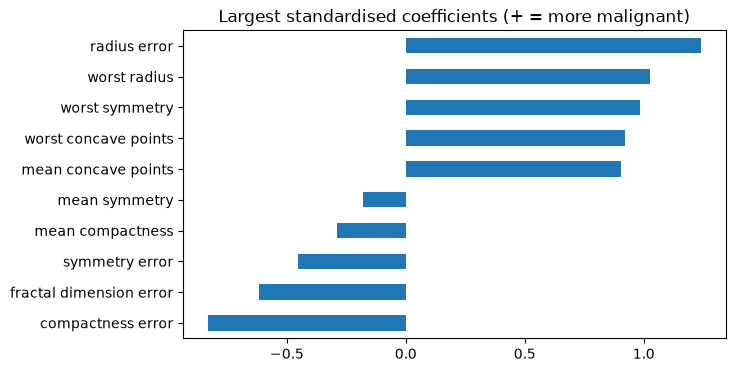

Hyperparameters: {'C': 1.0, 'max_iter': 1000, 'solver': 'lbfgs'}


In [7]:
lr = best.named_steps["logisticregression"]
coef = pd.Series(lr.coef_[0], index=X.columns).sort_values()
coef.iloc[np.r_[0:5, -5:0]].plot.barh(figsize=(7, 4), title="Largest standardised coefficients (+ = more malignant)")
plt.show()
print("Hyperparameters:", {k: v for k, v in lr.get_params().items() if k in ["C", "max_iter", "solver"]})

## **4. Datasets for Practice**

| Function | Type | Notes |
|---|---|---|
| `load_iris`, `load_wine`, `load_breast_cancer`, `load_digits` | classification | bundled, no download |
| `load_diabetes` | regression | bundled |
| `fetch_california_housing`, `fetch_openml(...)` | real data | downloads once |
| `make_classification`, `make_regression`, `make_blobs`, `make_moons`, `make_circles` | synthetic | full control of difficulty |

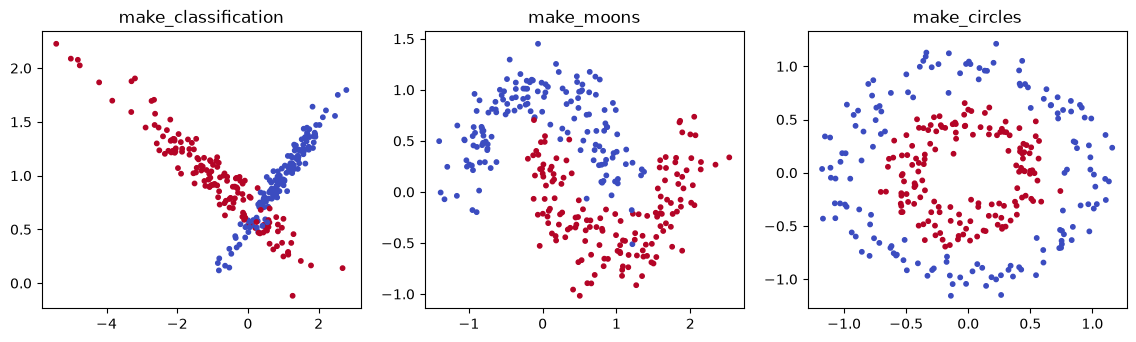

In [8]:
from sklearn.datasets import make_classification, make_moons, make_circles
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, (name, (Xs, ys)) in zip(axes, {"make_classification": make_classification(300, 2, n_redundant=0, n_informative=2, random_state=1, n_clusters_per_class=1),
                                        "make_moons": make_moons(300, noise=0.2, random_state=0),
                                        "make_circles": make_circles(300, noise=0.1, factor=0.5, random_state=0)}.items()):
    ax.scatter(Xs[:, 0], Xs[:, 1], c=ys, s=10, cmap="coolwarm"); ax.set_title(name)
plt.show()

# **Part 2: Going Deeper - Write Our Own Estimator**

Any class following the API conventions works with pipelines, cross-validation and grid search. Rules: store constructor arguments unchanged in `__init__`; learn in `fit` and return `self`; learned attributes end with `_`; inherit from `BaseEstimator` (gives `get_params`/`set_params`) and a mixin (gives `score`).

Below: a **Nearest Centroid / Minimum-Distance classifier** with an option for Euclidean or cosine (spectral-angle) distance.

In [9]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted

class MinimumDistanceClassifier(ClassifierMixin, BaseEstimator):
    def __init__(self, metric="euclidean"):
        self.metric = metric

    def fit(self, X, y):
        X, y = check_X_y(X, y)
        self.classes_ = np.unique(y)
        self.centroids_ = np.stack([X[y == c].mean(0) for c in self.classes_])
        return self

    def predict(self, X):
        check_is_fitted(self, "centroids_")
        X = check_array(X)
        if self.metric == "euclidean":
            d = np.linalg.norm(X[:, None, :] - self.centroids_[None], axis=-1)
        elif self.metric == "cosine":
            Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
            Cn = self.centroids_ / np.linalg.norm(self.centroids_, axis=1, keepdims=True)
            d = 1 - Xn @ Cn.T
        else:
            raise ValueError(f"unknown metric {self.metric}")
        return self.classes_[d.argmin(1)]

from sklearn.model_selection import GridSearchCV
gs = GridSearchCV(make_pipeline(StandardScaler(), MinimumDistanceClassifier()),
                  {"minimumdistanceclassifier__metric": ["euclidean", "cosine"]}, cv=5).fit(X_train, y_train)
print("Best metric:", gs.best_params_, "| CV accuracy:", round(gs.best_score_, 3), "| test:", round(gs.score(X_test, y_test), 3))

from sklearn.utils.estimator_checks import check_estimator
try:
    check_estimator(MinimumDistanceClassifier())
    print("Passes scikit-learn's estimator checks")
except Exception as e:
    print("Some strict checks fail (fine for teaching):", type(e).__name__, str(e)[:120])

Best metric: {'minimumdistanceclassifier__metric': 'cosine'} | CV accuracy: 0.939 | test: 0.881
Some strict checks fail (fine for teaching): AssertionError `MinimumDistanceClassifier.fit()` does not set the `n_features_in_` attribute. You might want to use `sklearn.utils.vali


## **Practice Problems**
1. Train a `GaussianNB` on the breast-cancer data with the same protocol. Where does it rank?
2. What attributes does a fitted `RandomForestClassifier` have? (Hint: `[a for a in dir(rf) if a.endswith('_') and not a.startswith('_')]`)
3. Use `DummyRegressor(strategy="median")` as a baseline for `load_diabetes` and compare its R^2 with `LinearRegression` (5-fold CV).
4. *(Advanced)* Add a `predict_proba` method to `MinimumDistanceClassifier` using a softmax of negative distances.

In [10]:
# Solution 1
from sklearn.naive_bayes import GaussianNB
print("GaussianNB CV AUC:", cross_val_score(GaussianNB(), X_train, y_train, cv=5, scoring="roc_auc").mean().round(4))
# Solution 2
rf = RandomForestClassifier(n_estimators=10, random_state=0).fit(X_train, y_train)
print([a for a in dir(rf) if a.endswith("_") and not a.startswith("_")])
# Solution 3
from sklearn.datasets import load_diabetes
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
Xd, yd = load_diabetes(return_X_y=True)
print("Dummy R2:", cross_val_score(DummyRegressor(strategy="median"), Xd, yd, cv=5).mean().round(3),
      "| Linear R2:", cross_val_score(LinearRegression(), Xd, yd, cv=5).mean().round(3))
# Solution 4
def _proba(self, X):
    X = check_array(X); d = np.linalg.norm(X[:, None, :] - self.centroids_[None], axis=-1)
    e = np.exp(-(d - d.min(1, keepdims=True))); return e / e.sum(1, keepdims=True)
MinimumDistanceClassifier.predict_proba = _proba
mdc = make_pipeline(StandardScaler(), MinimumDistanceClassifier()).fit(X_train, y_train)
print("AUC with softmax-distance probabilities:", round(roc_auc_score(y_test, mdc.predict_proba(X_test)[:, 1]), 3))

GaussianNB CV AUC: 0.9859
['classes_', 'estimator_', 'estimators_', 'estimators_samples_', 'feature_importances_', 'feature_names_in_', 'n_classes_', 'n_features_in_', 'n_outputs_']
Dummy R2: -0.045 | Linear R2: 0.482
AUC with softmax-distance probabilities: 0.976


## **Key References**
- Pedregosa, F. et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825-2830.
- Buitinck, L. et al. (2013). API design for machine learning software: experiences from the scikit-learn project. *ECML PKDD Workshop*. arXiv:1309.0238.
- Geron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.), Chapter 2. O'Reilly.